In [8]:
import io
import os
import fnmatch
from typing import List, Optional
import paramiko
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

def load_features_importance(ip: str,
                             user: str,
                             password: str,
                            remote_dir: str,
                            model: str 
                            ) -> Optional[pd.DataFrame]:
    
    transport = None
    sftp = None
    remote_dir = remote_dir + '/' + model
    try:
        # Establish SFTP connection
        transport = paramiko.Transport((ip, 22))
        transport.connect(username=user, password=password)
        sftp = paramiko.SFTPClient.from_transport(transport)

        # List files in the remote directory
        files = sftp.listdir(remote_dir)
        pattern = f"features_importance.pkl"
        matched_files = fnmatch.filter(files, pattern)

        if not matched_files:
            print(f"No files matching pattern {pattern} found in {remote_dir}")
            return None
        
        # Sort files by modification time and get the latest one
        matched_files.sort(key=lambda x: sftp.stat(os.path.join(remote_dir, x)).st_mtime, reverse=True)
        latest_file = matched_files[0]
        remote_file_path = os.path.join(remote_dir, latest_file)

        # Read the CSV file into a pandas DataFrame
        with sftp.open(remote_file_path, "rb") as f:
            obj = pickle.load(f)

        if isinstance(obj, pd.DataFrame):
            return obj
        try:
            return pd.DataFrame(obj)
        except Exception as e:
            print("Le pickle n'est pas un DataFrame et n'est pas convertible en DataFrame.")
            return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None
    
    finally:
        # Fermeture propre
        try:
            if sftp is not None:
                sftp.close()
        finally:
            if transport is not None:
                transport.close()

In [10]:
IP = "mesohelios1.univ-fcomte.fr"
USER = "ncaron"
PASSWORD = "xp2nrfeu"
REMOTE_DIR = "/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node"
model = "catboost_search_full_10_all_one_nbsinister-kmeans-5-Class-Dept_classification_softmax"

features_importance = load_features_importance(
    ip=IP,
    user=USER,
    password=PASSWORD,
    remote_dir=REMOTE_DIR,
    model=model
)

/tmp/ipykernel_9930/1112932222.py:43: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = pickle.load(f)


In [11]:
features_importance

,mean_abs_shap,stdev_abs_shap,name,class
5,3.306247e-01,1.813823e-01,id_encoder,0
24,1.632824e-01,1.110604e-01,cluster_encoder,0
12,1.360114e-01,6.948372e-02,rhum_mean,0
161,1.322685e-01,1.487131e-01,Past_risk,0
3,9.769363e-02,6.554334e-02,fwi_max,0
...,...,...,...,...
78,5.612701e-06,6.014455e-05,snow24h16_min,4
46,3.515818e-06,9.925753e-07,couvrefeux,4
156,6.495166e-07,1.681778e-07,kbdi_min,4
92,0.000000e+00,0.000000e+00,sum_consecutive_rainfall_min,4


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def plot_features_importance_abs_mean_by_class(
    df: pd.DataFrame,
    top_n: int = 20,
    value_col: str = "mean_abs_shap",
    feature_col: str = "name",
    class_col: str = "class",
    annotate: bool = True,
    cmap_name: str = "viridis",  # ex: "viridis", "plasma", "inferno", "magma", "cividis", "tab20"
    rotate_xticks: int = 45
):
    """
    Calcule Mean(|SHAP|) moyenné par classe puis entre classes pour chaque feature,
    sélectionne le Top-N et trace un barplot vertical (features sur l'axe X) avec un colormap.

    Paramètres
    ----------
    df : DataFrame avec colonnes [value_col, feature_col, class_col]
    top_n : nombre de features affichées
    annotate : affiche la valeur au-dessus de chaque barre
    cmap_name : colormap matplotlib pour colorer les barres
    rotate_xticks : rotation des labels X (degrés)

    Retour
    ------
    fig, ax, top_series
    """
    expected = {value_col, feature_col, class_col}
    missing = expected - set(df.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes: {missing}. Requises: {expected}")

    work = df[[value_col, feature_col, class_col]].dropna(subset=[value_col, feature_col, class_col]).copy()
    work["abs_val"] = work[value_col].abs()

    # Moyenne par (feature, classe)
    class_means = work.groupby([feature_col, class_col], dropna=False)["abs_val"].mean()

    # Moyenne entre classes (par feature)
    feature_means = class_means.groupby(level=0).mean().sort_values(ascending=False)

    # Top-N (garder l'ordre décroissant pour l'affichage de gauche à droite)
    top_series = feature_means.head(top_n)

    # Préparer les couleurs en fonction des valeurs
    vals = top_series.values
    vmin, vmax = float(np.min(vals)), float(np.max(vals))
    # éviter division par zéro si toutes valeurs identiques
    normed = (vals - vmin) / (vmax - vmin) if vmax > vmin else np.zeros_like(vals)
    cmap = cm.get_cmap(cmap_name)
    colors = cmap(normed)

    # Taille de figure adaptée au nombre de barres
    width = max(6.0, 0.6 * len(top_series) + 1.5)
    fig, ax = plt.subplots(figsize=(width, 5.5))

    bars = ax.bar(top_series.index.astype(str), top_series.values, color=colors, edgecolor="none")

    ax.set_ylabel("Mean(|SHAP|)")
    ax.set_xlabel("Feature")
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)

    # Rotation/ajustement des labels X
    if rotate_xticks:
        plt.setp(ax.get_xticklabels(), rotation=rotate_xticks, ha="right")

    # Annotations
    if annotate:
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{v:.4g}",
                    ha="center", va="bottom")

    plt.tight_layout()
    return fig, ax, top_series

/tmp/ipykernel_9930/3943753749.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


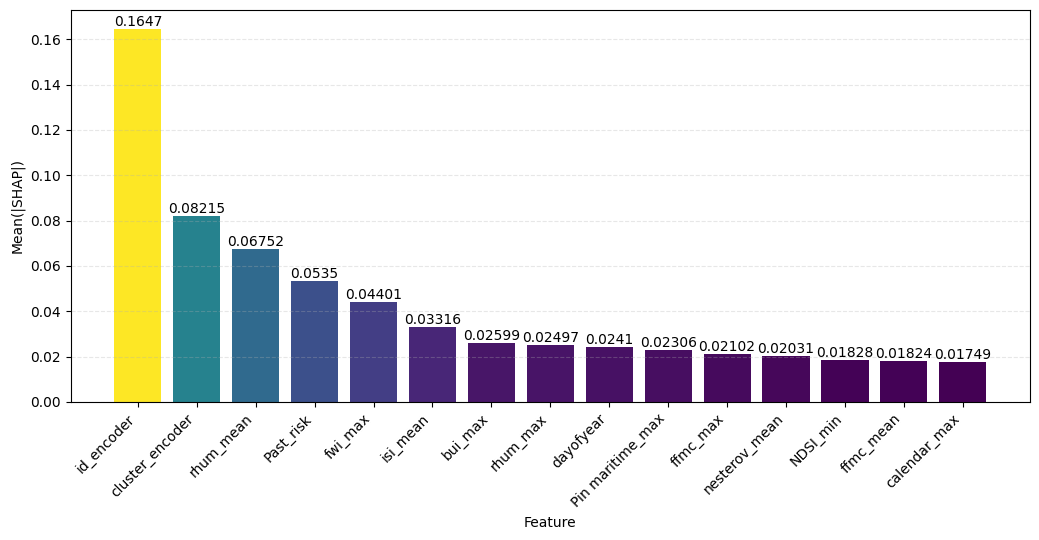

In [21]:
fig, ax, top_vals = plot_features_importance_abs_mean_by_class(features_importance, top_n=15)